# Credit Card Fraud Detection — TrustGuard

**Goal:** Build a high-recall, low-false-positive fraud detection system on highly imbalanced transaction data.

**Dataset:** [Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/brml/creditcardfraud) — 284,807 transactions, 492 frauds (0.17%)

**Pipeline:**
1. EDA + class imbalance analysis
2. Preprocessing (scaling, train/test split with stratification)
3. Baseline model (Logistic Regression)
4. Handle imbalance (SMOTE / class weights)
5. Train XGBoost / LightGBM
6. Evaluate: Precision, Recall, F1, AUC-ROC, AUC-PR, confusion matrix
7. Feature importance (SHAP)
8. Threshold tuning for business tradeoff (precision vs recall)

## 0. Setup

In [1]:
!pip install -q imbalanced-learn xgboost lightgbm shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, auc, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data

Download `creditcard.csv` from Kaggle and upload to Colab, or use the Kaggle API:
```python
from google.colab import files
files.upload()  # upload kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mlg-ulb/creditcardfraud --unzip
```

In [2]:
df = pd.read_csv('creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. EDA — Class Imbalance

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


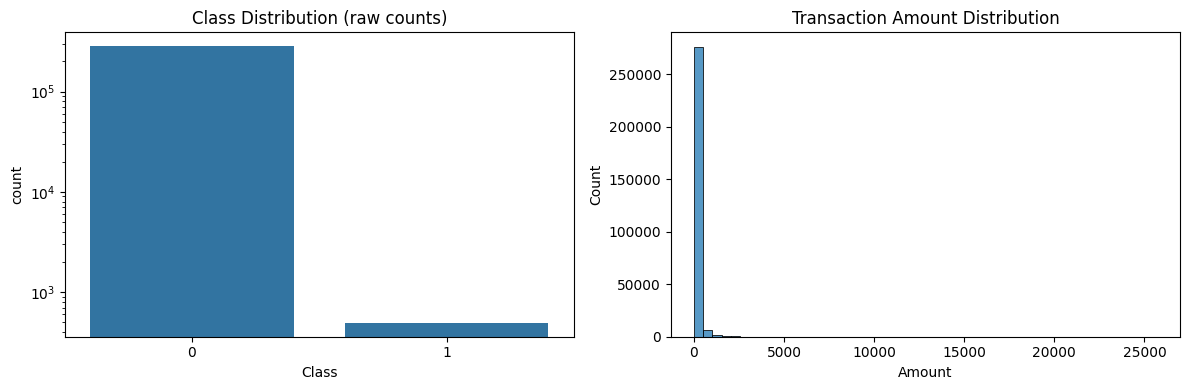

In [3]:
fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100
print(fraud_count)
print(fraud_pct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Class', data=df, ax=ax[0])
ax[0].set_title('Class Distribution (raw counts)')
ax[0].set_yscale('log')

sns.histplot(df['Amount'], bins=50, ax=ax[1])
ax[1].set_title('Transaction Amount Distribution')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [4]:
X = df.drop(columns=['Class'])
y = df['Class']

scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train fraud rate: {y_train.mean():.4%}")
print(f"Test fraud rate:  {y_test.mean():.4%}")

Train fraud rate: 0.1729%
Test fraud rate:  0.1720%


## 4. Baseline — Logistic Regression (class-weighted)

In [5]:
baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
y_proba_base = baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_base, digits=4))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"AUC-PR:  {average_precision_score(y_test, y_proba_base):.4f}")

              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0609    0.9184    0.1141        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5509     56962
weighted avg     0.9982    0.9755    0.9861     56962

AUC-ROC: 0.9722
AUC-PR:  0.7189


## 5. SMOTE Resampling + XGBoost

In [6]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train_sm, y_train_sm)

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

## 6. Evaluation

              precision    recall  f1-score   support

           0     0.9998    0.9990    0.9994     56864
           1     0.6071    0.8673    0.7143        98

    accuracy                         0.9988     56962
   macro avg     0.8035    0.9332    0.8568     56962
weighted avg     0.9991    0.9988    0.9989     56962

AUC-ROC: 0.9769
AUC-PR:  0.8619
F1:      0.7143


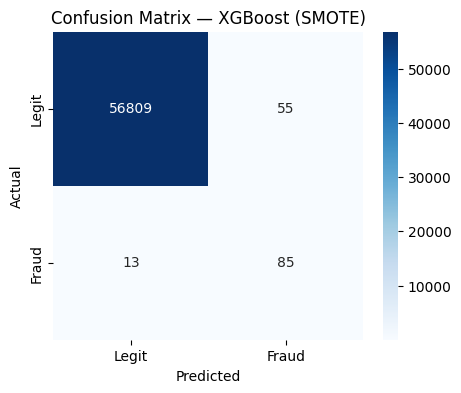

In [7]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"AUC-PR:  {average_precision_score(y_test, y_proba):.4f}")
print(f"F1:      {f1_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — XGBoost (SMOTE)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

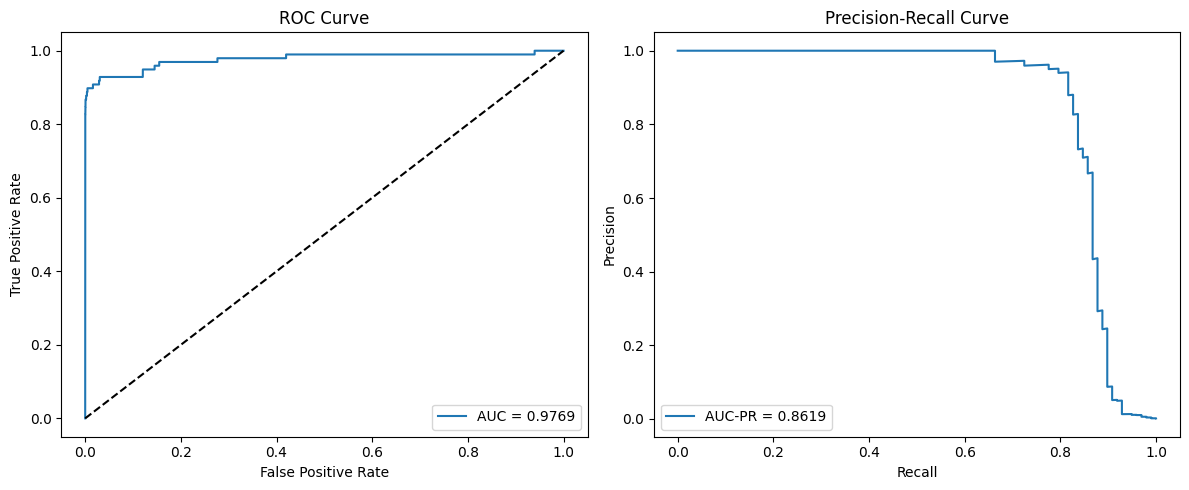

In [8]:
# ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend()

ax[1].plot(recall, precision, label=f'AUC-PR = {average_precision_score(y_test, y_proba):.4f}')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend()

plt.tight_layout()
plt.show()

## 7. Feature Importance (SHAP)

/tmp/ipykernel_1749/669223154.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=15)


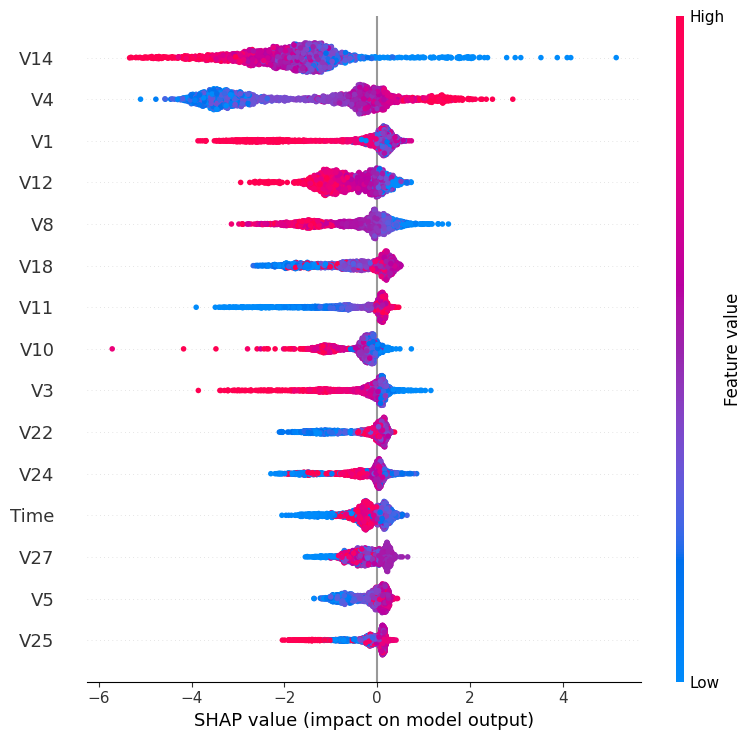

In [9]:
explainer = shap.TreeExplainer(xgb_model)
# Sample for speed
X_sample = X_test.sample(2000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, max_display=15)

## 8. Threshold Tuning — Business Tradeoff

Default threshold (0.5) isn't always optimal. For fraud detection, missing a fraud (false negative)
is usually costlier than a false alarm (false positive). Sweep thresholds to find the best tradeoff.

In [10]:
thresholds = np.arange(0.1, 0.95, 0.05)
results = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'precision': classification_report(y_test, preds, output_dict=True)['1']['precision'],
        'recall': classification_report(y_test, preds, output_dict=True)['1']['recall'],
        'f1': f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
results_df

,threshold,precision,recall,f1
0,0.10,0.241096,0.897959,0.380130
1,0.15,0.307143,0.877551,0.455026
2,0.20,0.365957,0.877551,0.516517
3,0.25,0.423645,0.877551,0.571429
4,0.30,0.464481,0.867347,0.604982
5,0.35,0.500000,0.867347,0.634328
6,0.40,0.548387,0.867347,0.671937
7,0.45,0.582192,0.867347,0.696721
8,0.50,0.607143,0.867347,0.714286
9,0.55,0.648855,0.867347,0.742358


## 9. Save Model

In [11]:
import joblib
joblib.dump(xgb_model, 'fraud_xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved.")

Model and scaler saved.


## 10. Summary of Results

Fill in your final numbers here after running the notebook:

| Model | Precision | Recall | F1 | AUC-ROC | AUC-PR |
|---|---|---|---|---|---|
| Logistic Regression (baseline) | 0.0609 | 0.9184 | 0.1141 | 0.9722 | 0.7189 |
| XGBoost + SMOTE | 0.6071 | 0.8673 | 0.7143 | 0.9769 | 0.8619 |